# 🏥 Disease Prediction System using Machine Learning
## Healthcare Analytics Project

---
### Objectives
- Predict diseases based on patient symptoms and medical data
- Assist doctors in early diagnosis
- Improve healthcare decision-making
- Reduce diagnostic time and cost

### System Flow
`Data Collection → Preprocessing → EDA → Feature Engineering → Model Training → Evaluation → Prediction`

---
## 📦 Step 0: Import Libraries

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Sklearn - Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')
COLORS = sns.color_palette('Set2', 8)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 1: Data Collection

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('C:\\Users\\Samay\\OneDrive\\Documents\\glowlogics_projects\\Disease Prediction\\data\\dataset.csv')

print('='*60)
print('📊 DATASET OVERVIEW')
print('='*60)
print(f'Total Records   : {df.shape[0]:,}')
print(f'Total Features  : {df.shape[1]}')
print(f'Disease Classes : {df["Disease"].nunique()}')
print('\n📋 First 5 Rows:')
display(df.head())

print('\n📋 Dataset Info:')
df.info()

📊 DATASET OVERVIEW
Total Records   : 2,000
Total Features  : 20
Disease Classes : 8

📋 First 5 Rows:


,Patient_ID,Age,Gender,Fever,Cough,Fatigue,Body_Ache,Headache,Chest_Pain,Shortness_of_Breath,Nausea,Dizziness,Frequent_Urination,Increased_Thirst,Blurred_Vision,Blood_Pressure,Sugar_Level,Cholesterol,Medical_History,Disease
0,P00001,78,Male,0,0,1,0,1,0,1,1,1,0,0,0,158/108,119,205,Asthma,Hypertension
1,P00002,12,Male,1,1,0,1,1,0,0,0,0,0,1,0,115/77,108,195,Hypertension,Flu
2,P00003,44,Male,0,0,1,0,1,0,0,0,1,0,0,0,196/122,105,225,Heart_Disease,Hypertension
3,P00004,32,Male,0,0,0,0,0,0,0,0,0,0,0,0,116/82,94,161,NaN,Healthy
4,P00005,60,Male,1,1,1,1,1,0,0,1,0,1,0,1,131/89,102,180,NaN,Flu



📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Patient_ID           2000 non-null   str  
 1   Age                  2000 non-null   int64
 2   Gender               2000 non-null   str  
 3   Fever                2000 non-null   int64
 4   Cough                2000 non-null   int64
 5   Fatigue              2000 non-null   int64
 6   Body_Ache            2000 non-null   int64
 7   Headache             2000 non-null   int64
 8   Chest_Pain           2000 non-null   int64
 9   Shortness_of_Breath  2000 non-null   int64
 10  Nausea               2000 non-null   int64
 11  Dizziness            2000 non-null   int64
 12  Frequent_Urination   2000 non-null   int64
 13  Increased_Thirst     2000 non-null   int64
 14  Blurred_Vision       2000 non-null   int64
 15  Blood_Pressure       2000 non-null   str  
 16  Sugar_Level       

---
## 🔧 Step 2: Data Preprocessing

🔍 MISSING VALUE ANALYSIS


                 Missing Count  Missing %
Medical_History           1244       62.2


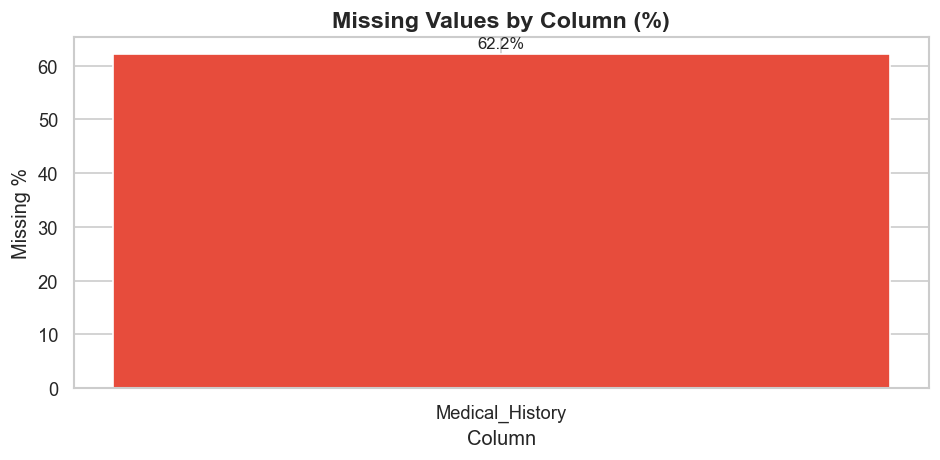

In [3]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================
print('='*60)
print('🔍 MISSING VALUE ANALYSIS')
print('='*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(missing_df.index, missing_df['Missing %'], color='#E74C3C', edgecolor='white')
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

In [4]:
# ============================================================
# FEATURE ENGINEERING & PREPROCESSING
# ============================================================
df_clean = df.copy()

# 1. Drop non-informative column
df_clean.drop(columns=['Patient_ID'], inplace=True)

# 2. Parse Blood Pressure → Systolic & Diastolic
df_clean[['BP_Systolic', 'BP_Diastolic']] = (
    df_clean['Blood_Pressure'].str.split('/', expand=True).astype(int)
)
df_clean.drop(columns=['Blood_Pressure'], inplace=True)

# 3. Encode Gender (Male=1, Female=0)
df_clean['Gender'] = LabelEncoder().fit_transform(df_clean['Gender'])

# 4. Handle Medical_History (fill NaN with 'None', then encode)
df_clean['Medical_History'] = df_clean['Medical_History'].fillna('None')
df_clean['Medical_History'] = LabelEncoder().fit_transform(df_clean['Medical_History'])

# 5. Engineer new features
symptom_cols = ['Fever','Cough','Fatigue','Body_Ache','Headache',
                'Chest_Pain','Shortness_of_Breath','Nausea','Dizziness',
                'Frequent_Urination','Increased_Thirst','Blurred_Vision']
df_clean['Symptom_Count']    = df_clean[symptom_cols].sum(axis=1)
df_clean['BP_Pulse_Pressure'] = df_clean['BP_Systolic'] - df_clean['BP_Diastolic']
df_clean['Risk_Score']        = (
    df_clean['Symptom_Count'] * 2 +
    (df_clean['BP_Systolic'] > 140).astype(int) * 3 +
    (df_clean['Sugar_Level'] > 140).astype(int) * 3 +
    (df_clean['Cholesterol'] > 200).astype(int) * 2
)

# 6. Encode target
le_disease = LabelEncoder()
df_clean['Disease_Encoded'] = le_disease.fit_transform(df_clean['Disease'])

print('✅ Preprocessing complete!')
print(f'Engineered Features: Symptom_Count, BP_Pulse_Pressure, Risk_Score')
print(f'Shape after preprocessing: {df_clean.shape}')
display(df_clean.head(3))

✅ Preprocessing complete!
Engineered Features: Symptom_Count, BP_Pulse_Pressure, Risk_Score
Shape after preprocessing: (2000, 24)


,Age,Gender,Fever,Cough,Fatigue,Body_Ache,Headache,Chest_Pain,Shortness_of_Breath,Nausea,...,Sugar_Level,Cholesterol,Medical_History,Disease,BP_Systolic,BP_Diastolic,Symptom_Count,BP_Pulse_Pressure,Risk_Score,Disease_Encoded
0,78,1,0,0,1,0,1,0,1,1,...,119,205,0,Hypertension,158,108,5,50,15,5
1,12,1,1,1,0,1,1,0,0,0,...,108,195,3,Flu,115,77,5,38,10,2
2,44,1,0,0,1,0,1,0,0,0,...,105,225,2,Hypertension,196,122,3,74,11,5


---
## 📊 Step 3: Exploratory Data Analysis (EDA)

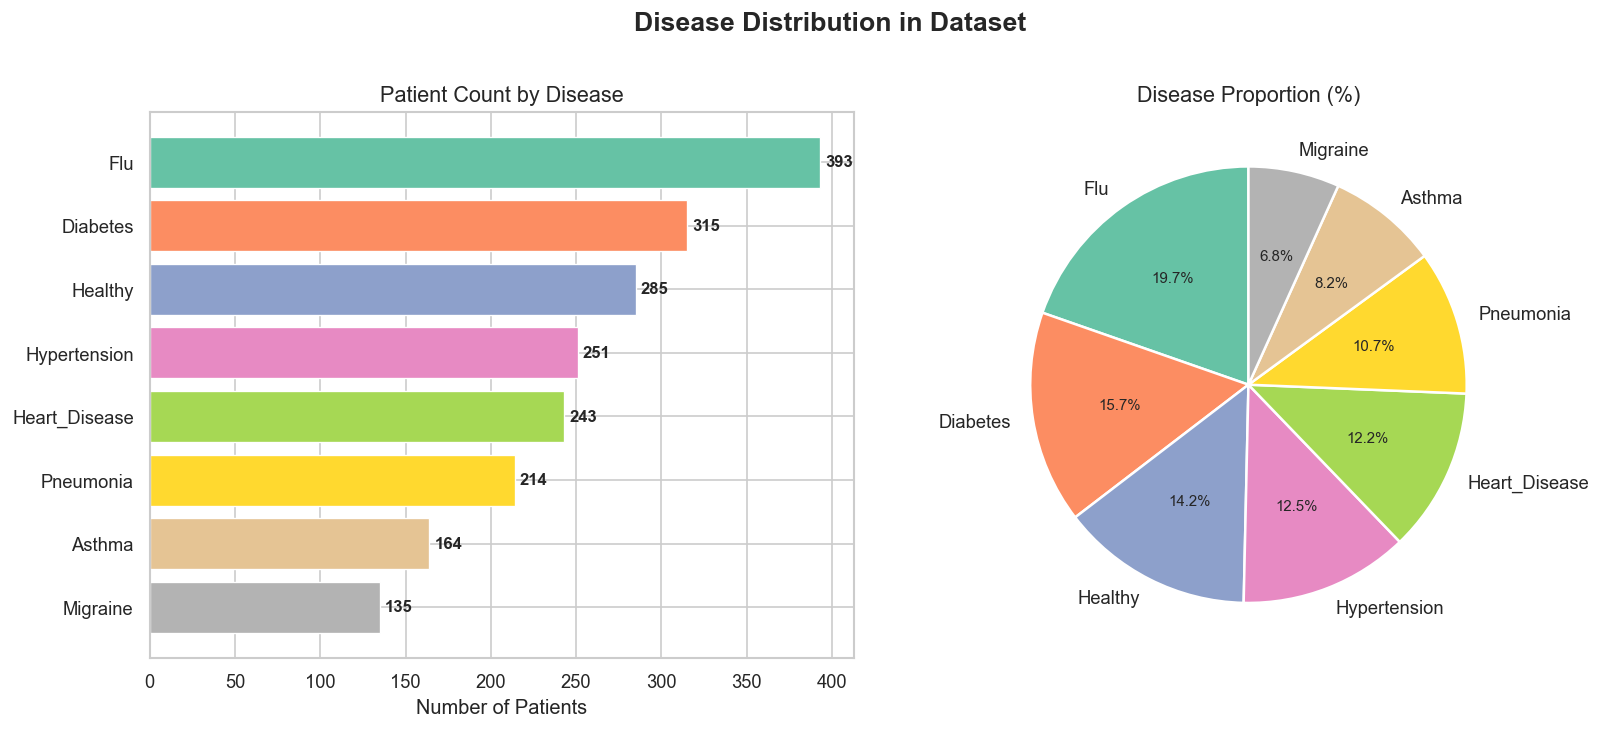

In [5]:
# ============================================================
# EDA - DISEASE DISTRIBUTION
# ============================================================
disease_counts = df['Disease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Disease Distribution in Dataset', fontsize=16, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].barh(disease_counts.index, disease_counts.values,
                     color=COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title('Patient Count by Disease', fontsize=13)
axes[0].set_xlabel('Number of Patients')
for bar, val in zip(bars, disease_counts.values):
    axes[0].text(val + 3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')
axes[0].invert_yaxis()

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    disease_counts.values, labels=disease_counts.index,
    autopct='%1.1f%%', colors=COLORS, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Disease Proportion (%)', fontsize=13)

plt.tight_layout()
plt.savefig('disease_distribution.png', bbox_inches='tight')
plt.show()

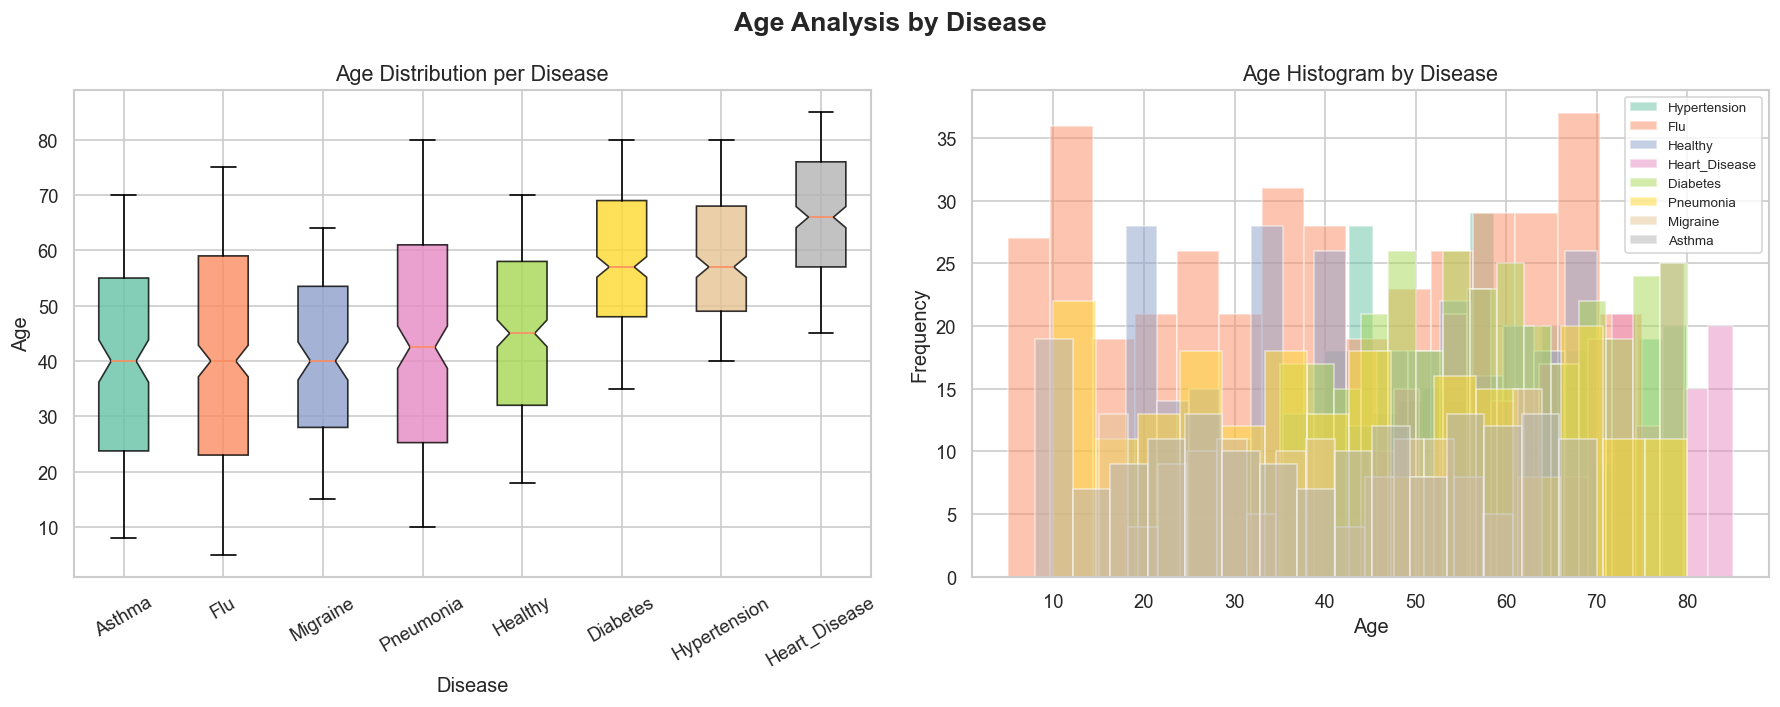

In [6]:
# ============================================================
# EDA - AGE DISTRIBUTION BY DISEASE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Age Analysis by Disease', fontsize=16, fontweight='bold')

# Box plot
order = df.groupby('Disease')['Age'].median().sort_values().index.tolist()
df_sorted = df.copy()
df_sorted['Disease'] = pd.Categorical(df_sorted['Disease'], categories=order, ordered=True)
bp = axes[0].boxplot(
    [df[df['Disease']==d]['Age'].values for d in order],
    labels=order, patch_artist=True, notch=True
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('Age Distribution per Disease', fontsize=13)
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Age')
axes[0].tick_params(axis='x', rotation=30)

# Histogram overlay
for i, disease in enumerate(df['Disease'].unique()):
    subset = df[df['Disease'] == disease]['Age']
    axes[1].hist(subset, bins=15, alpha=0.5, label=disease,
                 color=COLORS[i % len(COLORS)], edgecolor='white')
axes[1].set_title('Age Histogram by Disease', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('age_analysis.png', bbox_inches='tight')
plt.show()

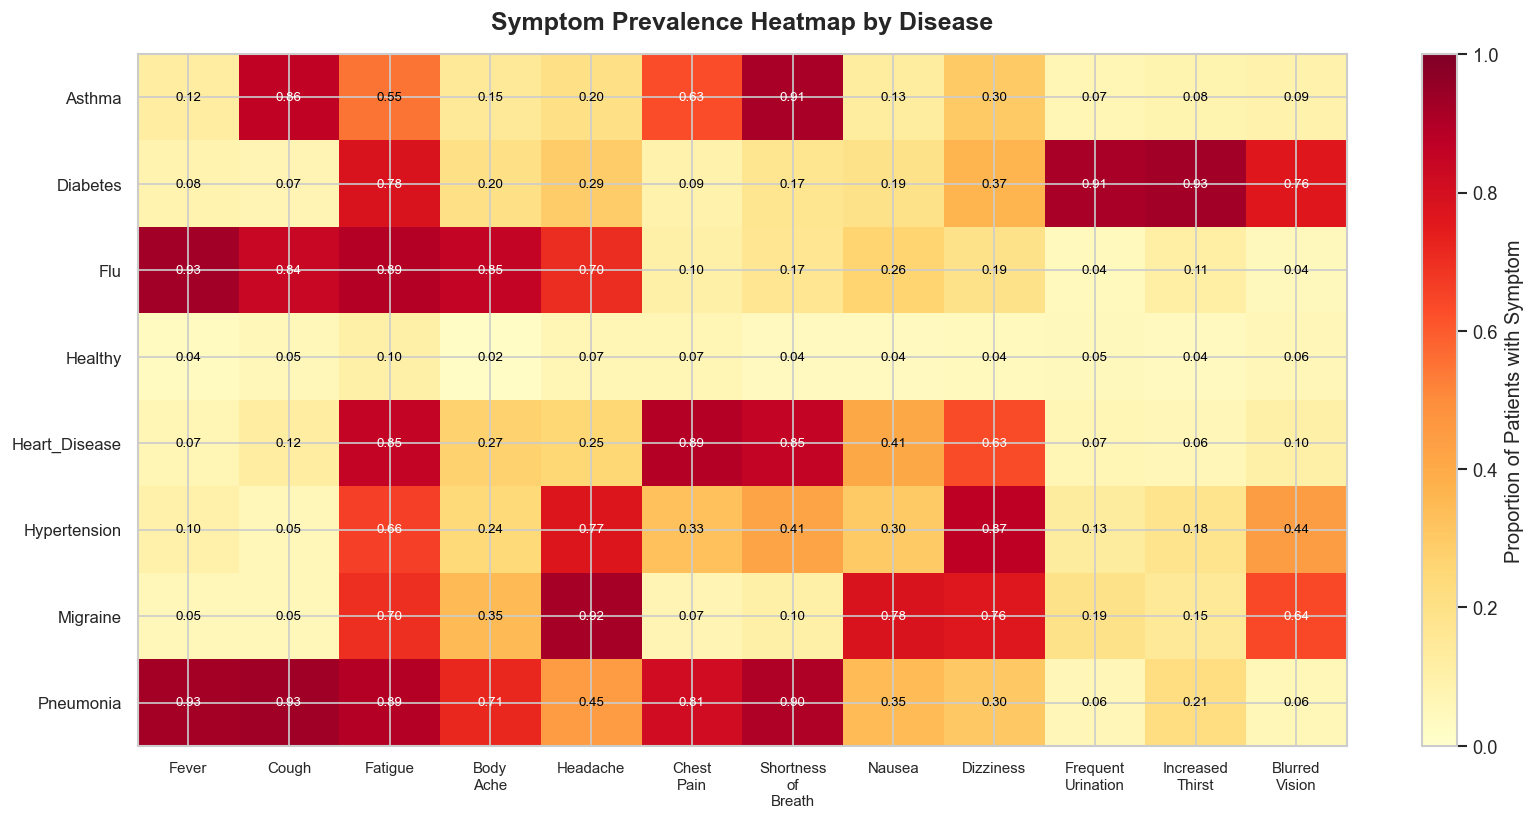

In [7]:
# ============================================================
# EDA - SYMPTOM PREVALENCE BY DISEASE
# ============================================================
symptom_by_disease = df.groupby('Disease')[symptom_cols].mean()

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(symptom_by_disease.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(symptom_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in symptom_cols], fontsize=9)
ax.set_yticks(range(len(symptom_by_disease.index)))
ax.set_yticklabels(symptom_by_disease.index, fontsize=10)
ax.set_title('Symptom Prevalence Heatmap by Disease', fontsize=15, fontweight='bold', pad=15)

for i in range(len(symptom_by_disease.index)):
    for j in range(len(symptom_cols)):
        val = symptom_by_disease.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='black' if val < 0.6 else 'white')

plt.colorbar(im, ax=ax, label='Proportion of Patients with Symptom')
plt.tight_layout()
plt.savefig('symptom_heatmap.png', bbox_inches='tight')
plt.show()

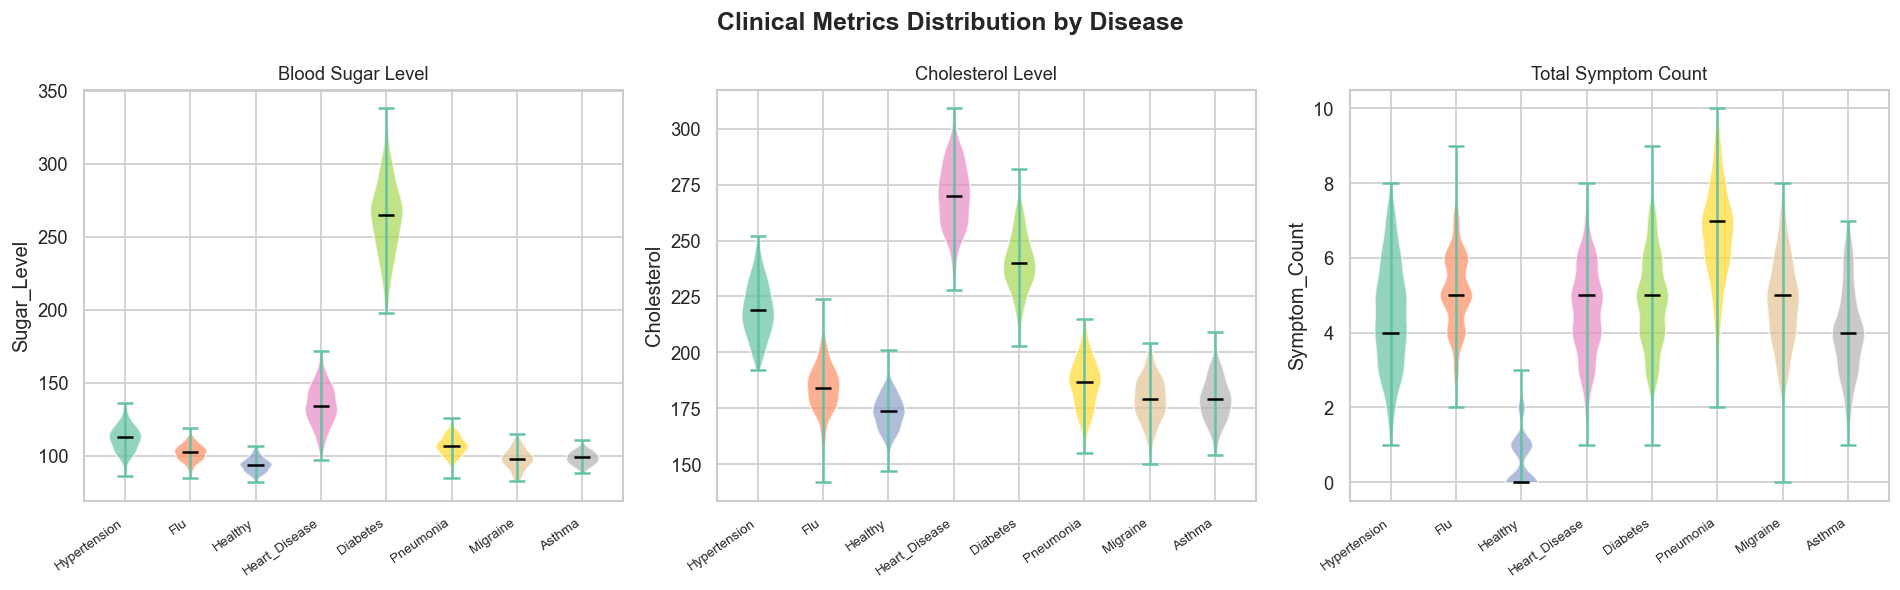

In [8]:
# ============================================================
# EDA - CLINICAL METRICS BY DISEASE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Clinical Metrics Distribution by Disease', fontsize=15, fontweight='bold')

metrics = ['Sugar_Level', 'Cholesterol', 'Symptom_Count']
titles  = ['Blood Sugar Level', 'Cholesterol Level', 'Total Symptom Count']

for ax, metric, title in zip(axes, metrics, titles):
    data = [df_clean[df_clean['Disease'] == d][metric].dropna().values
            for d in df['Disease'].unique()]
    vp = ax.violinplot(data, showmedians=True, showmeans=False)
    for i, pc in enumerate(vp['bodies']):
        pc.set_facecolor(COLORS[i % len(COLORS)])
        pc.set_alpha(0.7)
    vp['cmedians'].set_color('black')
    ax.set_xticks(range(1, len(df['Disease'].unique()) + 1))
    ax.set_xticklabels(df['Disease'].unique(), rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig('clinical_metrics.png', bbox_inches='tight')
plt.show()

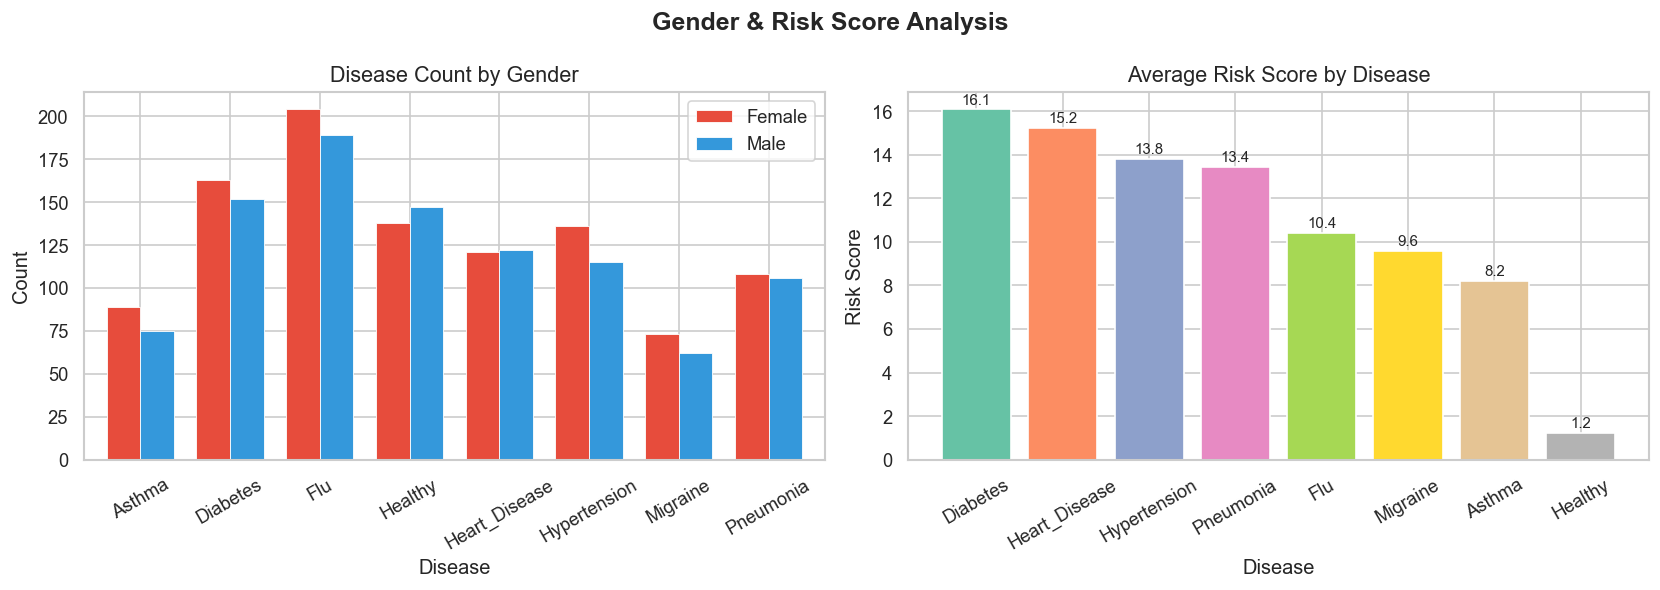

In [9]:
# ============================================================
# EDA - GENDER & RISK SCORE ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender & Risk Score Analysis', fontsize=15, fontweight='bold')

# Gender distribution
gender_disease = df.groupby(['Disease', 'Gender']).size().unstack(fill_value=0)
gender_disease.plot(kind='bar', ax=axes[0], color=['#E74C3C', '#3498DB'],
                    edgecolor='white', linewidth=0.5, width=0.75)
axes[0].set_title('Disease Count by Gender', fontsize=13)
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Female', 'Male'])

# Risk score
risk_by_disease = df_clean.groupby('Disease')['Risk_Score'].mean().sort_values(ascending=False)
bars = axes[1].bar(risk_by_disease.index, risk_by_disease.values,
                   color=COLORS[:len(risk_by_disease)], edgecolor='white')
axes[1].set_title('Average Risk Score by Disease', fontsize=13)
axes[1].set_xlabel('Disease')
axes[1].set_ylabel('Risk Score')
axes[1].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('gender_risk.png', bbox_inches='tight')
plt.show()

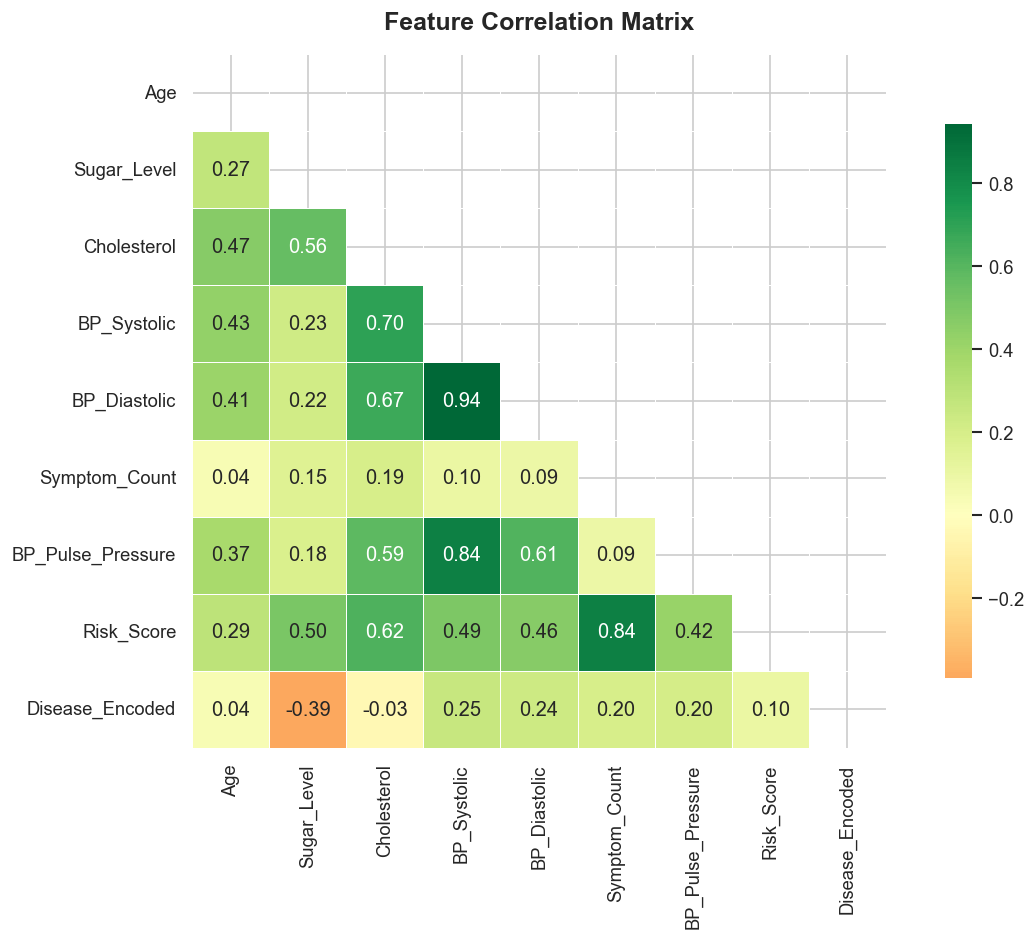

In [10]:
# ============================================================
# EDA - CORRELATION HEATMAP
# ============================================================
num_cols = ['Age', 'Sugar_Level', 'Cholesterol', 'BP_Systolic', 'BP_Diastolic',
            'Symptom_Count', 'BP_Pulse_Pressure', 'Risk_Score', 'Disease_Encoded']

corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

---
## 🤖 Step 4–6: Model Training & Selection

In [11]:
# ============================================================
# PREPARE FEATURES & SPLIT DATA
# ============================================================
feature_cols = [
    'Age', 'Gender', 'Medical_History',
    'Fever', 'Cough', 'Fatigue', 'Body_Ache', 'Headache',
    'Chest_Pain', 'Shortness_of_Breath', 'Nausea', 'Dizziness',
    'Frequent_Urination', 'Increased_Thirst', 'Blurred_Vision',
    'BP_Systolic', 'BP_Diastolic', 'Sugar_Level', 'Cholesterol',
    'Symptom_Count', 'BP_Pulse_Pressure', 'Risk_Score'
]

X = df_clean[feature_cols]
y = df_clean['Disease_Encoded']

# Train/Test split: 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Data split complete!')
print(f'   Training samples : {X_train.shape[0]:,}')
print(f'   Testing  samples : {X_test.shape[0]:,}')
print(f'   Features         : {X_train.shape[1]}')
print(f'   Disease classes  : {y.nunique()} → {le_disease.classes_.tolist()}')

✅ Data split complete!
   Training samples : 1,600
   Testing  samples : 400
   Features         : 22
   Disease classes  : 8 → ['Asthma', 'Diabetes', 'Flu', 'Healthy', 'Heart_Disease', 'Hypertension', 'Migraine', 'Pneumonia']


In [12]:
# ============================================================
# DEFINE & TRAIN ALL MODELS
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'SVM'                : SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}
trained = {}

print('🔄 Training models...')
print('='*65)
for name, model in models.items():
    # Use scaled data for LR, SVM; raw for tree models & NB
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv_m = cv_scores.mean()

    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'CV Mean': cv_m
    }
    trained[name] = (model, y_pred)

    print(f'  {name:<22} | Acc: {acc:.4f} | F1: {f1:.4f} | CV: {cv_m:.4f}')

print('='*65)
print('✅ All models trained!')

🔄 Training models...
  Logistic Regression    | Acc: 0.9325 | F1: 0.9323 | CV: 0.9300
  Decision Tree          | Acc: 0.9175 | F1: 0.9169 | CV: 0.8906
  Random Forest          | Acc: 0.9375 | F1: 0.9371 | CV: 0.9325
  Naive Bayes            | Acc: 0.9150 | F1: 0.9163 | CV: 0.9225
  SVM                    | Acc: 0.9375 | F1: 0.9370 | CV: 0.9256
✅ All models trained!


---
## 📈 Step 7–8: Model Evaluation & Results

In [13]:
# ============================================================
# RESULTS SUMMARY TABLE
# ============================================================
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df = results_df.map(lambda x: round(x * 100, 2))

print('='*65)
print('📊 MODEL PERFORMANCE SUMMARY (%)')
print('='*65)
display(results_df.style
    .background_gradient(cmap='Greens', axis=None)
    .format('{:.2f}%')
    .set_caption('Model Comparison — Higher is Better')
)

best_model_name = results_df.index[0]
print(f'\n🏆 Best Model: {best_model_name} — Accuracy: {results_df.loc[best_model_name, "Accuracy"]:.2f}%')

📊 MODEL PERFORMANCE SUMMARY (%)


,Accuracy,Precision,Recall,F1-Score,CV Mean
Random Forest,93.75%,93.86%,93.75%,93.71%,93.25%
SVM,93.75%,93.78%,93.75%,93.70%,92.56%
Logistic Regression,93.25%,93.43%,93.25%,93.23%,93.00%
Decision Tree,91.75%,91.79%,91.75%,91.69%,89.06%
Naive Bayes,91.50%,91.93%,91.50%,91.63%,92.25%



🏆 Best Model: Random Forest — Accuracy: 93.75%


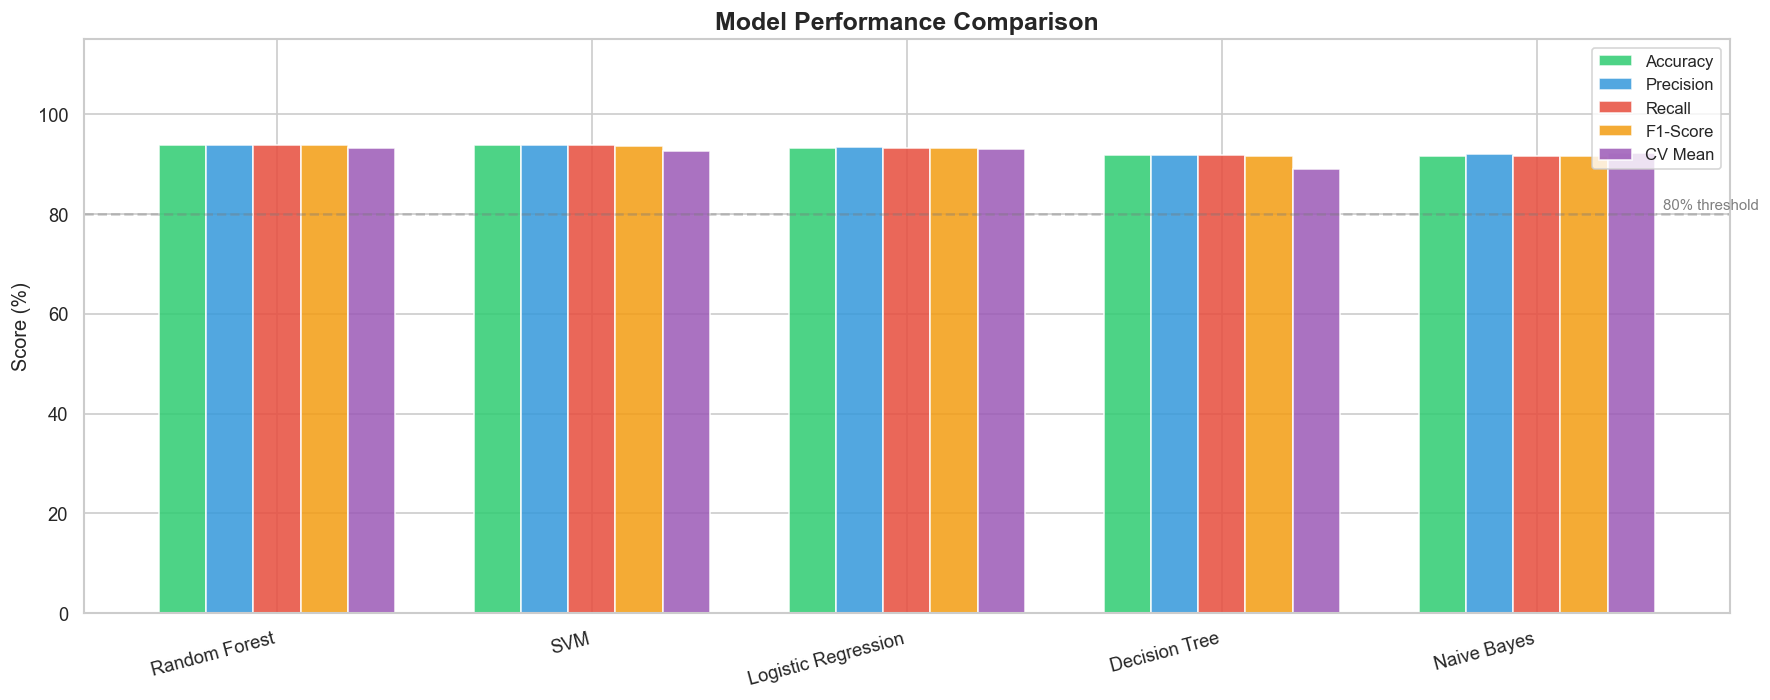

In [14]:
# ============================================================
# MODEL COMPARISON BAR CHARTS
# ============================================================
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean']
model_names     = results_df.index.tolist()
x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
palette = ['#2ECC71','#3498DB','#E74C3C','#F39C12','#9B59B6']

for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
    vals = [results[m][metric] * 100 for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4, label='80% threshold')
ax.text(len(model_names)-0.3, 81, '80% threshold', color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

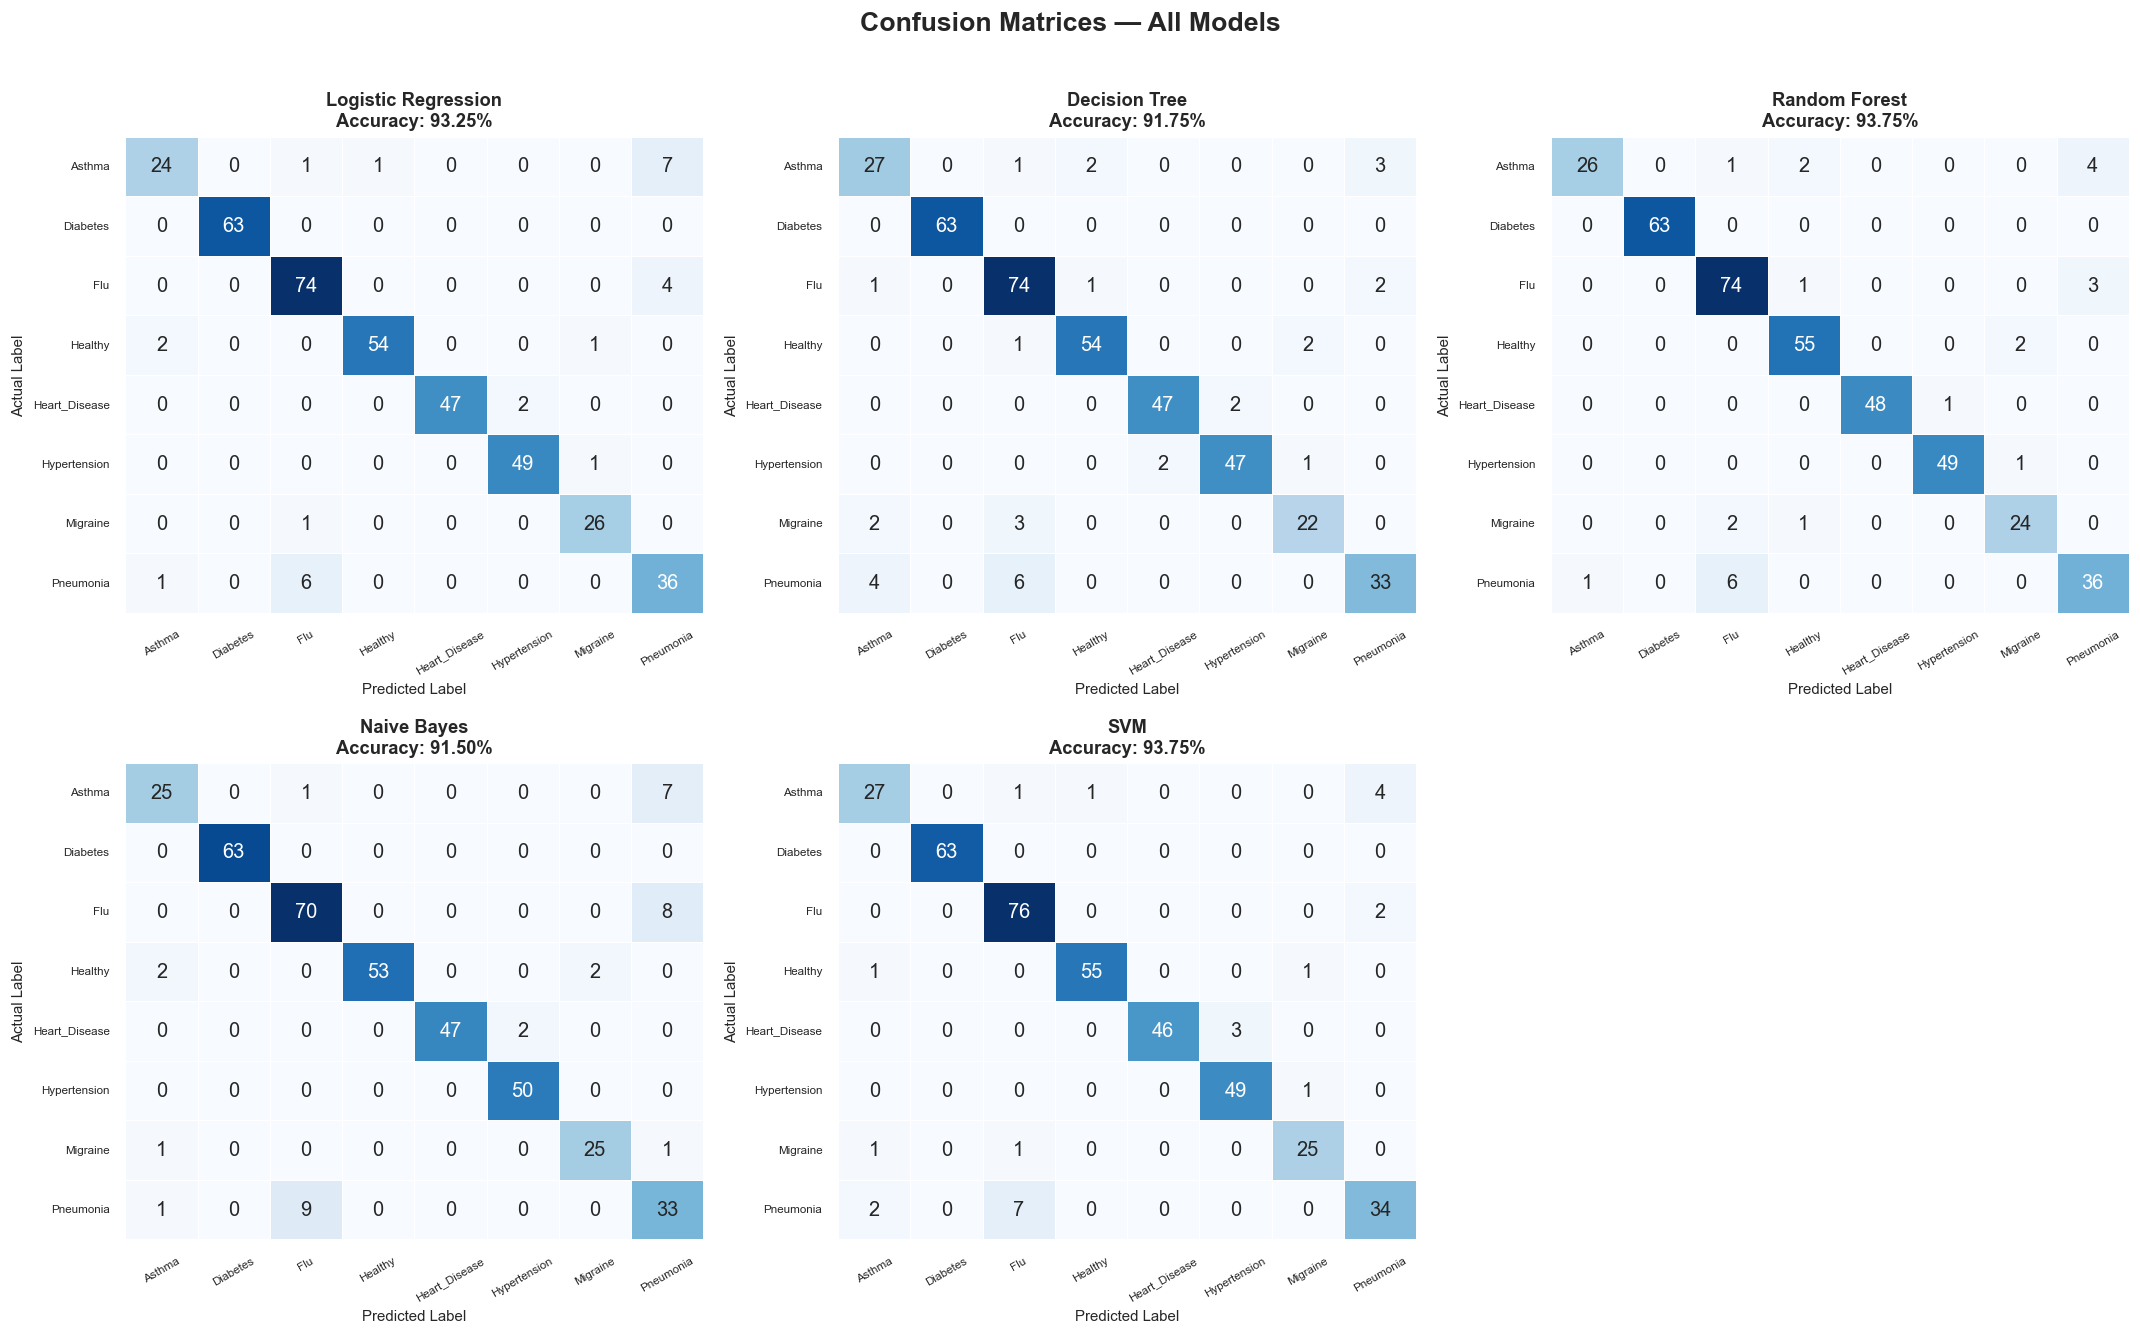

In [15]:
# ============================================================
# CONFUSION MATRICES — ALL MODELS
# ============================================================
disease_labels = le_disease.classes_
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, (name, (model, y_pred)) in enumerate(trained.items()):
    ax = axes_flat[idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=disease_labels, yticklabels=disease_labels,
                linewidths=0.3, cbar=False)
    acc = results[name]['Accuracy'] * 100
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('Actual Label', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

# Hide last empty subplot
axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# DETAILED CLASSIFICATION REPORT — BEST MODEL
# ============================================================
best_model, best_preds = trained[best_model_name]

print(f'📋 Classification Report — {best_model_name}')
print('='*65)
print(classification_report(
    y_test, best_preds,
    target_names=disease_labels
))

📋 Classification Report — Random Forest
               precision    recall  f1-score   support

       Asthma       0.96      0.79      0.87        33
     Diabetes       1.00      1.00      1.00        63
          Flu       0.89      0.95      0.92        78
      Healthy       0.93      0.96      0.95        57
Heart_Disease       1.00      0.98      0.99        49
 Hypertension       0.98      0.98      0.98        50
     Migraine       0.89      0.89      0.89        27
    Pneumonia       0.84      0.84      0.84        43

     accuracy                           0.94       400
    macro avg       0.94      0.92      0.93       400
 weighted avg       0.94      0.94      0.94       400



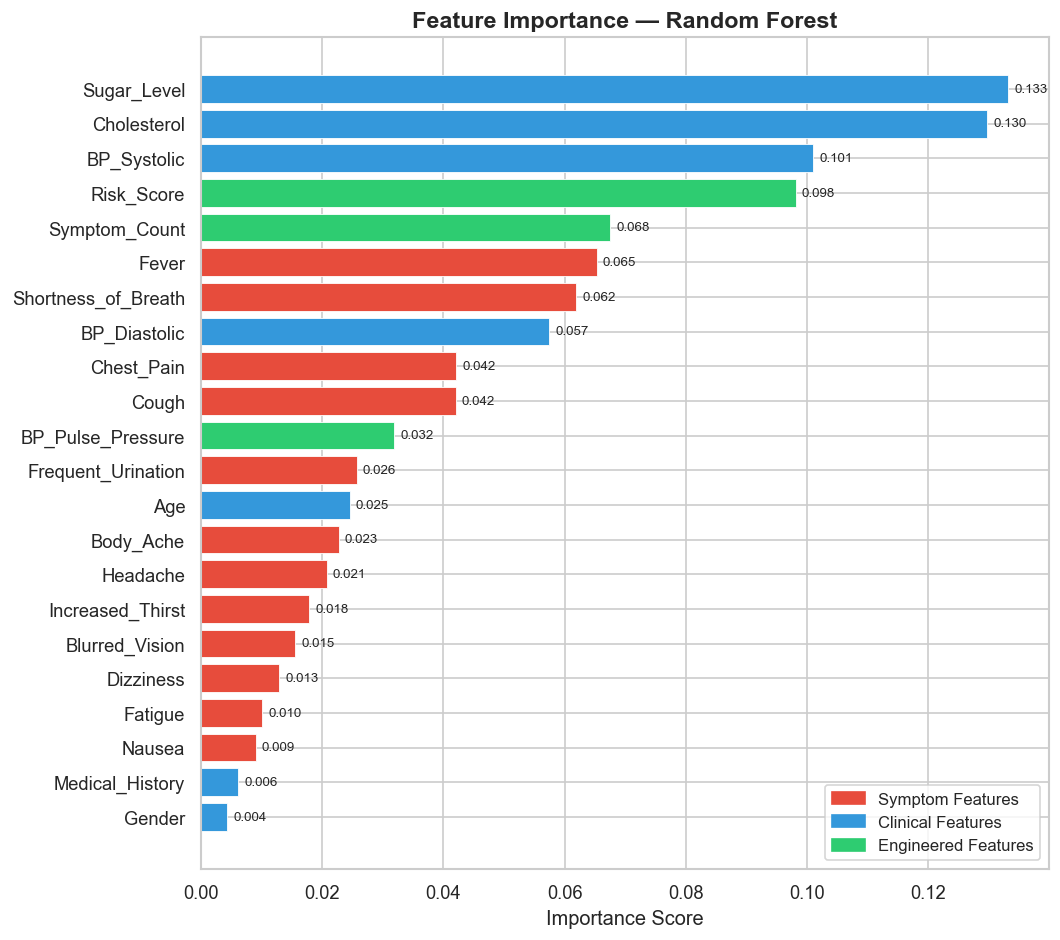

In [17]:
# ============================================================
# FEATURE IMPORTANCE (Random Forest)
# ============================================================
rf_model = trained['Random Forest'][0]
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=True)

# Color coding: green = engineered, blue = clinical, salmon = symptoms
color_map = []
engineered = {'Symptom_Count', 'BP_Pulse_Pressure', 'Risk_Score'}
clinical   = {'Age', 'Gender', 'Medical_History', 'BP_Systolic',
               'BP_Diastolic', 'Sugar_Level', 'Cholesterol'}
for f in feat_imp.index:
    if f in engineered: color_map.append('#2ECC71')
    elif f in clinical:  color_map.append('#3498DB')
    else:                color_map.append('#E74C3C')

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=color_map, edgecolor='white', linewidth=0.5)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

legend_patches = [
    mpatches.Patch(color='#E74C3C', label='Symptom Features'),
    mpatches.Patch(color='#3498DB', label='Clinical Features'),
    mpatches.Patch(color='#2ECC71', label='Engineered Features'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

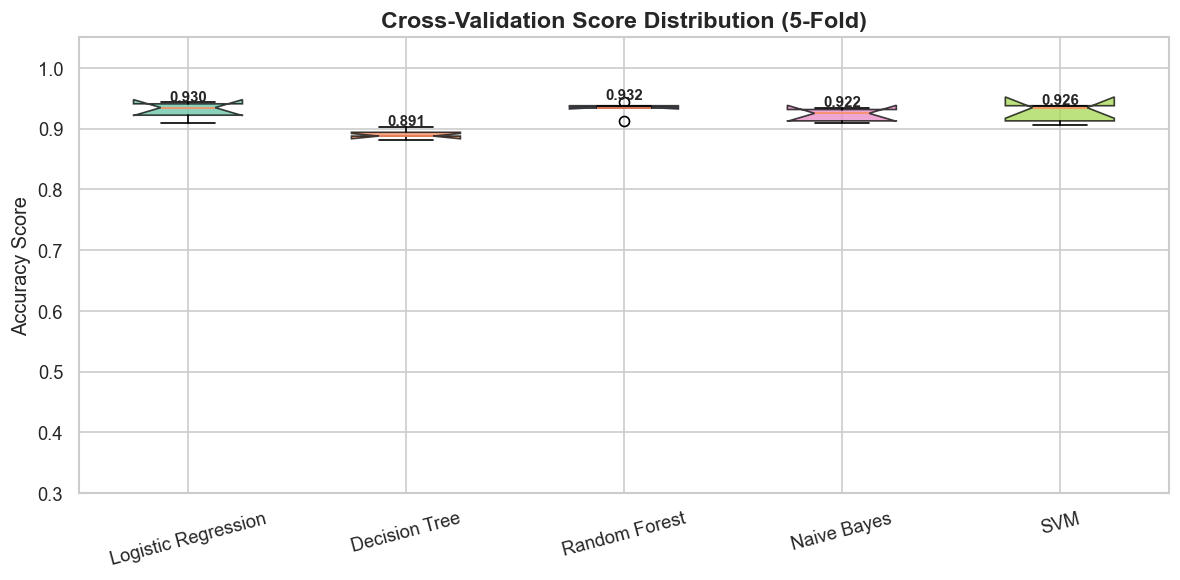

In [18]:
# ============================================================
# CROSS-VALIDATION SCORE COMPARISON
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = {}
for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        scores = cross_val_score(model, X_train_sc, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_data[name] = scores

bp = ax.boxplot([v for v in cv_data.values()], labels=list(cv_data.keys()),
                patch_artist=True, notch=True, vert=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Cross-Validation Score Distribution (5-Fold)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy Score')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0.3, 1.05)

for i, (name, scores) in enumerate(cv_data.items(), 1):
    ax.text(i, scores.mean() + 0.01, f'{scores.mean():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

---
##  Step 9: Disease Prediction — Patient Input

In [19]:
# ============================================================
# DISEASE PREDICTION FUNCTION
# ============================================================

RISK_LEVELS = {
    'Healthy': '🟢 LOW',
    'Flu': '🟡 MODERATE',
    'Migraine': '🟡 MODERATE',
    'Asthma': '🟠 HIGH',
    'Pneumonia': '🟠 HIGH',
    'Diabetes': '🔴 HIGH',
    'Hypertension': '🔴 HIGH',
    'Heart_Disease': '🔴 CRITICAL',
}

def predict_disease(patient: dict, use_model='Random Forest'):
    """
    Predict disease for a patient given their symptoms and medical values.
    patient: dict with keys matching feature_cols (before engineering)
    """
    # Compute engineered features
    sym_cols = ['Fever','Cough','Fatigue','Body_Ache','Headache',
                'Chest_Pain','Shortness_of_Breath','Nausea','Dizziness',
                'Frequent_Urination','Increased_Thirst','Blurred_Vision']
    symptom_count = sum(patient.get(s, 0) for s in sym_cols)
    bp_sys  = patient.get('BP_Systolic', 120)
    bp_dia  = patient.get('BP_Diastolic', 80)
    sugar   = patient.get('Sugar_Level', 100)
    chol    = patient.get('Cholesterol', 180)

    risk_score = (
        symptom_count * 2 +
        int(bp_sys > 140) * 3 +
        int(sugar > 140) * 3 +
        int(chol > 200) * 2
    )

    input_row = pd.DataFrame([{
        'Age'               : patient.get('Age', 30),
        'Gender'            : 1 if patient.get('Gender','Male') == 'Male' else 0,
        'Medical_History'   : patient.get('Medical_History', 0),
        'Fever'             : patient.get('Fever', 0),
        'Cough'             : patient.get('Cough', 0),
        'Fatigue'           : patient.get('Fatigue', 0),
        'Body_Ache'         : patient.get('Body_Ache', 0),
        'Headache'          : patient.get('Headache', 0),
        'Chest_Pain'        : patient.get('Chest_Pain', 0),
        'Shortness_of_Breath': patient.get('Shortness_of_Breath', 0),
        'Nausea'            : patient.get('Nausea', 0),
        'Dizziness'         : patient.get('Dizziness', 0),
        'Frequent_Urination': patient.get('Frequent_Urination', 0),
        'Increased_Thirst'  : patient.get('Increased_Thirst', 0),
        'Blurred_Vision'    : patient.get('Blurred_Vision', 0),
        'BP_Systolic'       : bp_sys,
        'BP_Diastolic'      : bp_dia,
        'Sugar_Level'       : sugar,
        'Cholesterol'       : chol,
        'Symptom_Count'     : symptom_count,
        'BP_Pulse_Pressure' : bp_sys - bp_dia,
        'Risk_Score'        : risk_score,
    }])[feature_cols]

    model, _ = trained[use_model]
    if use_model in ['Logistic Regression', 'SVM']:
        input_sc = scaler.transform(input_row)
        pred     = model.predict(input_sc)[0]
        proba    = model.predict_proba(input_sc)[0]
    else:
        pred  = model.predict(input_row)[0]
        proba = model.predict_proba(input_row)[0]

    disease = le_disease.inverse_transform([pred])[0]
    top3    = np.argsort(proba)[::-1][:3]

    print('\n' + '='*55)
    print('  🏥 DISEASE PREDICTION REPORT')
    print('='*55)
    print(f'  Model Used       : {use_model}')
    print(f'  Predicted Disease: {disease}')
    print(f'  Risk Level       : {RISK_LEVELS.get(disease, "⚪ UNKNOWN")}')
    print(f'  Symptom Count    : {symptom_count}/12')
    print(f'  Risk Score       : {risk_score}')
    print('\n  📊 Top-3 Disease Probabilities:')
    for rank, i in enumerate(top3, 1):
        d_name = le_disease.classes_[i]
        print(f'  {rank}. {d_name:<18} → {proba[i]*100:.1f}%')
    print('='*55)
    return disease, proba

print('✅ Prediction function ready!')

✅ Prediction function ready!


In [20]:
# ============================================================
# SAMPLE PREDICTIONS — 3 PATIENT CASES
# ============================================================

# Patient 1 — Diabetic symptoms
patient_1 = {
    'Age': 55, 'Gender': 'Male', 'Medical_History': 0,
    'Fever': 0, 'Cough': 0, 'Fatigue': 1, 'Body_Ache': 0, 'Headache': 1,
    'Chest_Pain': 0, 'Shortness_of_Breath': 0, 'Nausea': 0, 'Dizziness': 1,
    'Frequent_Urination': 1, 'Increased_Thirst': 1, 'Blurred_Vision': 1,
    'BP_Systolic': 135, 'BP_Diastolic': 85, 'Sugar_Level': 220, 'Cholesterol': 195
}

# Patient 2 — Flu symptoms
patient_2 = {
    'Age': 28, 'Gender': 'Female', 'Medical_History': 0,
    'Fever': 1, 'Cough': 1, 'Fatigue': 1, 'Body_Ache': 1, 'Headache': 1,
    'Chest_Pain': 0, 'Shortness_of_Breath': 0, 'Nausea': 1, 'Dizziness': 0,
    'Frequent_Urination': 0, 'Increased_Thirst': 0, 'Blurred_Vision': 0,
    'BP_Systolic': 112, 'BP_Diastolic': 74, 'Sugar_Level': 90, 'Cholesterol': 165
}

# Patient 3 — Heart disease symptoms
patient_3 = {
    'Age': 67, 'Gender': 'Male', 'Medical_History': 1,
    'Fever': 0, 'Cough': 0, 'Fatigue': 1, 'Body_Ache': 0, 'Headache': 0,
    'Chest_Pain': 1, 'Shortness_of_Breath': 1, 'Nausea': 1, 'Dizziness': 1,
    'Frequent_Urination': 0, 'Increased_Thirst': 0, 'Blurred_Vision': 0,
    'BP_Systolic': 170, 'BP_Diastolic': 110, 'Sugar_Level': 130, 'Cholesterol': 280
}

print('───── PATIENT 1 (Diabetic Profile) ─────')
predict_disease(patient_1, 'Random Forest')

print('\n───── PATIENT 2 (Flu Profile) ─────')
predict_disease(patient_2, 'Random Forest')

print('\n───── PATIENT 3 (Cardiac Profile) ─────')
predict_disease(patient_3, 'Random Forest')

───── PATIENT 1 (Diabetic Profile) ─────

  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Diabetes
  Risk Level       : 🔴 HIGH
  Symptom Count    : 6/12
  Risk Score       : 15

  📊 Top-3 Disease Probabilities:
  1. Diabetes           → 60.5%
  2. Migraine           → 32.5%
  3. Hypertension       → 2.5%

───── PATIENT 2 (Flu Profile) ─────

  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Flu
  Risk Level       : 🟡 MODERATE
  Symptom Count    : 6/12
  Risk Score       : 12

  📊 Top-3 Disease Probabilities:
  1. Flu                → 94.9%
  2. Pneumonia          → 2.1%
  3. Migraine           → 2.0%

───── PATIENT 3 (Cardiac Profile) ─────

  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Heart_Disease
  Risk Level       : 🔴 CRITICAL
  Symptom Count    : 5/12
  Risk Score       : 15

  📊 Top-3 Disease Probabilities:
  1. Heart_Disease      → 98.4%
  2. Hypertension       → 1.

('Heart_Disease',
 array([0.      , 0.      , 0.      , 0.      , 0.984375, 0.015625,
        0.      , 0.      ]))


  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Diabetes
  Risk Level       : 🔴 HIGH
  Symptom Count    : 6/12
  Risk Score       : 15

  📊 Top-3 Disease Probabilities:
  1. Diabetes           → 60.5%
  2. Migraine           → 32.5%
  3. Hypertension       → 2.5%

  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Flu
  Risk Level       : 🟡 MODERATE
  Symptom Count    : 6/12
  Risk Score       : 12

  📊 Top-3 Disease Probabilities:
  1. Flu                → 94.9%
  2. Pneumonia          → 2.1%
  3. Migraine           → 2.0%

  🏥 DISEASE PREDICTION REPORT
  Model Used       : Random Forest
  Predicted Disease: Heart_Disease
  Risk Level       : 🔴 CRITICAL
  Symptom Count    : 5/12
  Risk Score       : 15

  📊 Top-3 Disease Probabilities:
  1. Heart_Disease      → 98.4%
  2. Hypertension       → 1.6%
  3. Pneumonia          → 0.0%


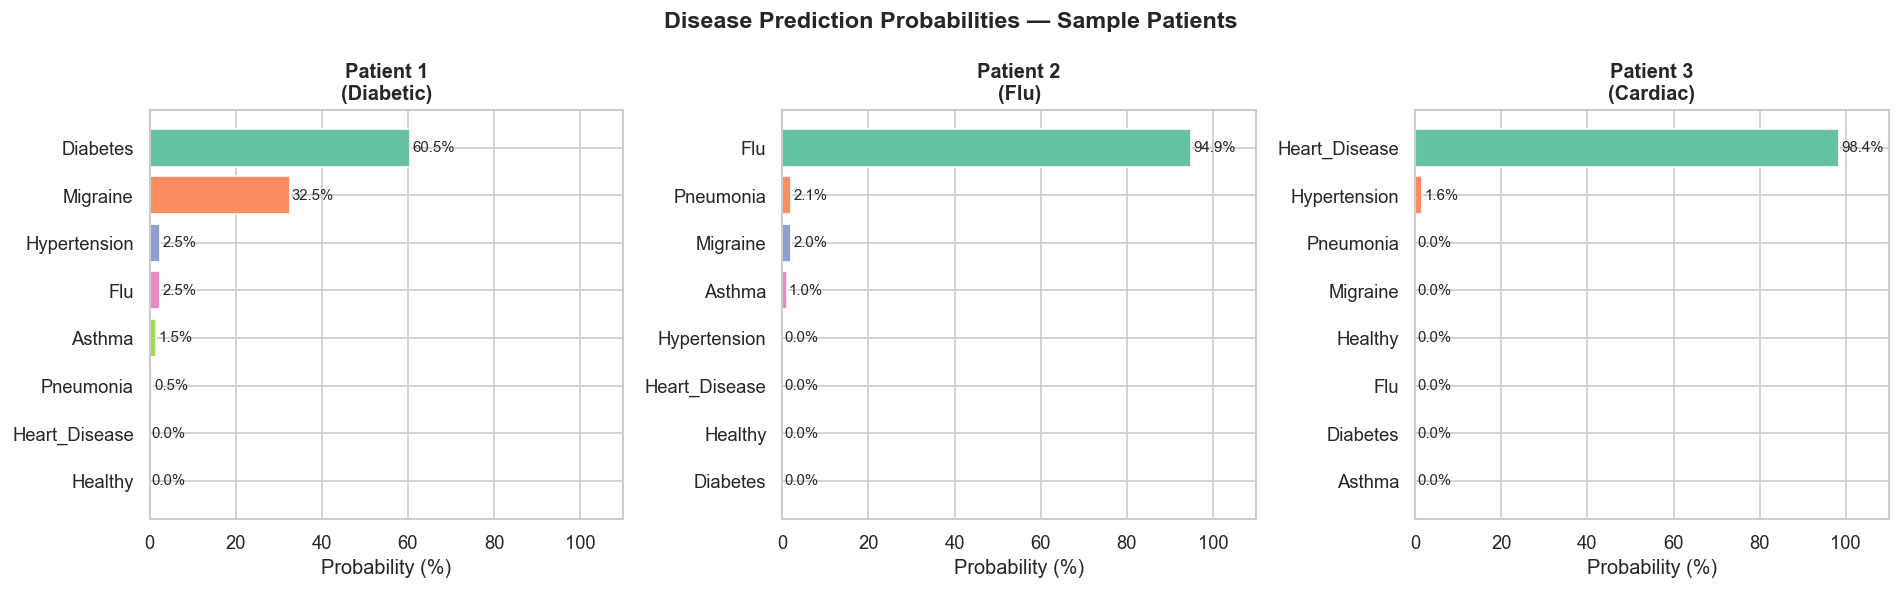

In [21]:
# ============================================================
# VISUAL — PREDICTION PROBABILITY CHART
# ============================================================
patients = [
    ('Patient 1\n(Diabetic)', patient_1),
    ('Patient 2\n(Flu)', patient_2),
    ('Patient 3\n(Cardiac)', patient_3),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Disease Prediction Probabilities — Sample Patients',
             fontsize=14, fontweight='bold')

model_rf = trained['Random Forest'][0]

for ax, (label, pat) in zip(axes, patients):
    _, proba = predict_disease(pat, 'Random Forest')
    sorted_idx = np.argsort(proba)[::-1]
    top_diseases = [le_disease.classes_[i] for i in sorted_idx]
    top_probs    = [proba[i] * 100 for i in sorted_idx]

    bar_colors = [COLORS[i % len(COLORS)] for i in range(len(top_diseases))]
    bars = ax.barh(top_diseases[::-1], top_probs[::-1],
                   color=bar_colors[::-1], edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Probability (%)')
    ax.set_xlim(0, 110)
    for bar in bars:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('prediction_probabilities.png', bbox_inches='tight')
plt.show()

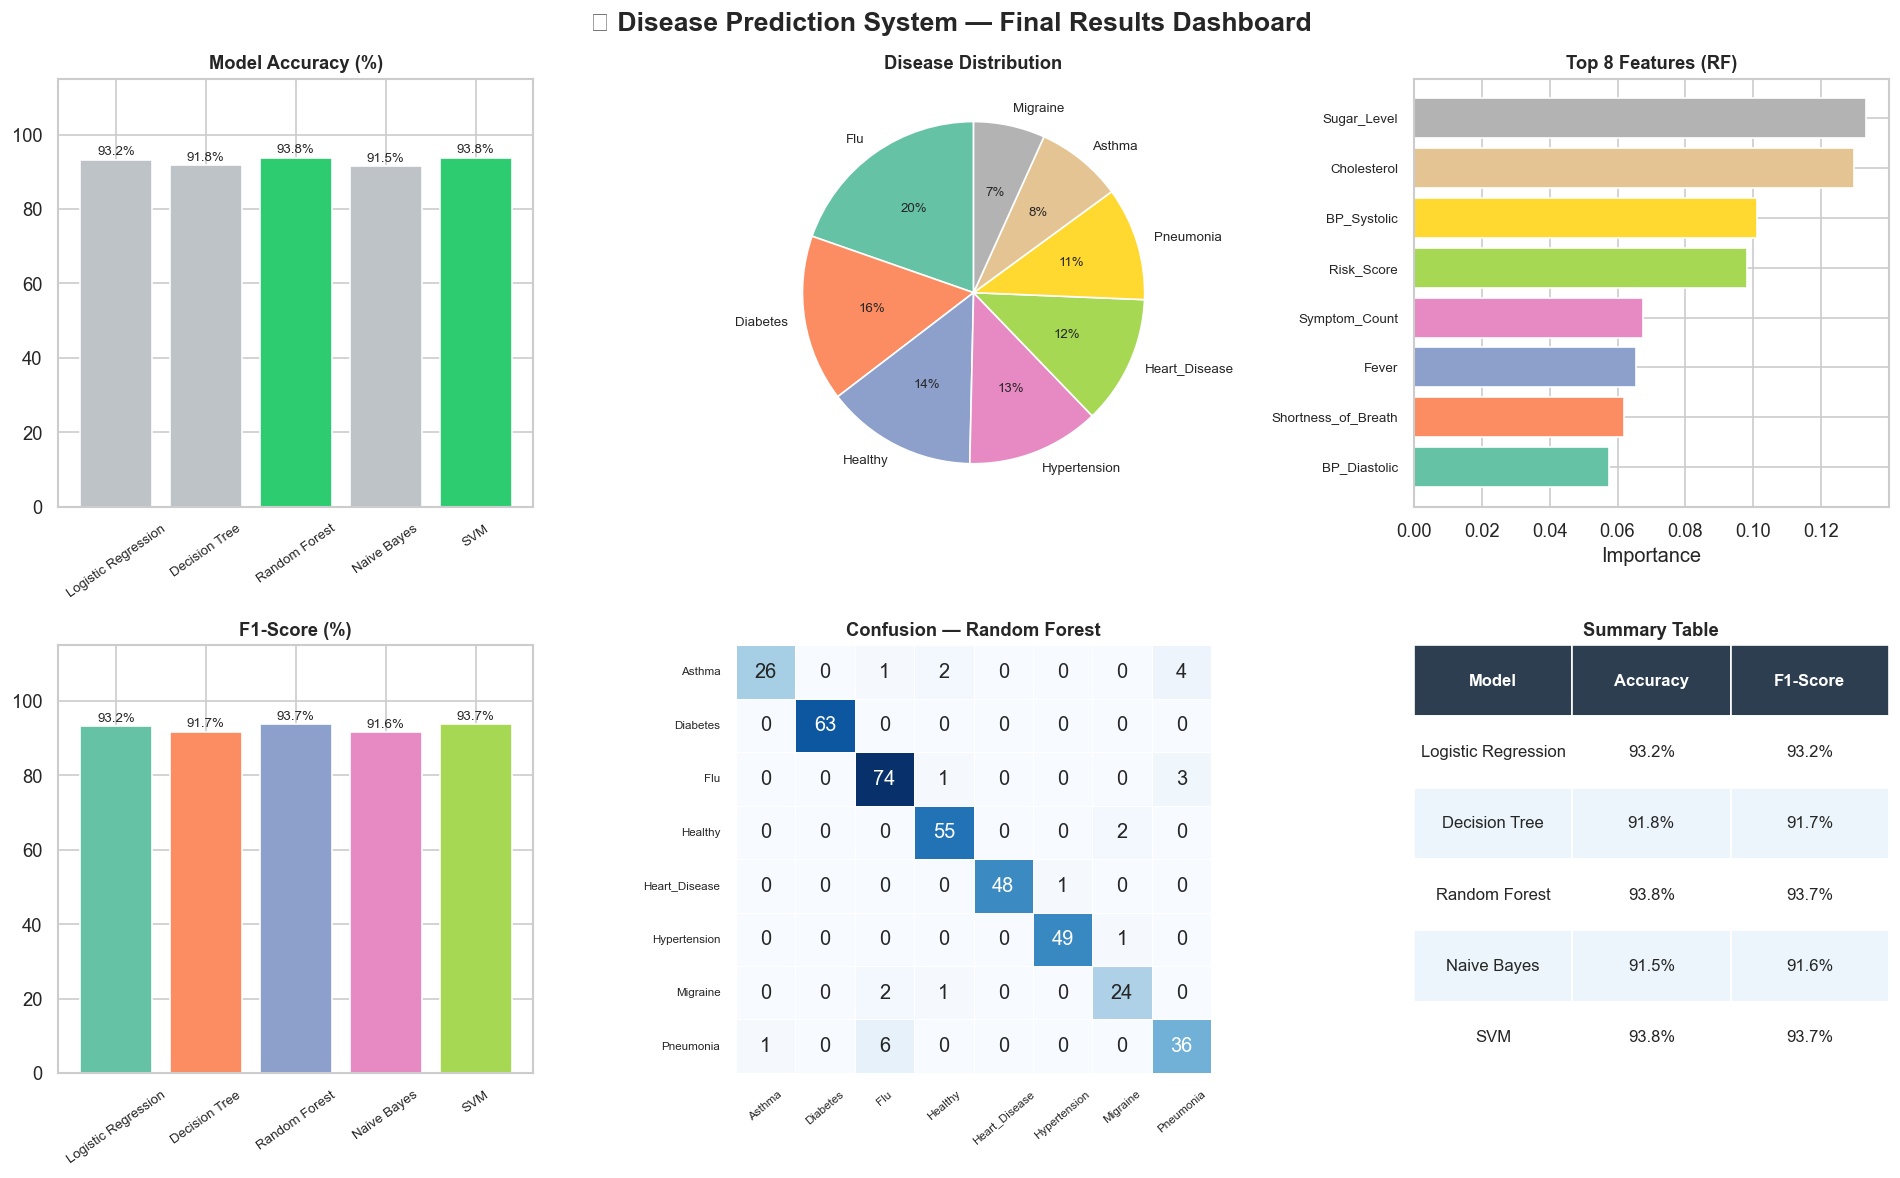

✅ Dashboard saved!


In [22]:
# ============================================================
# FINAL SUMMARY DASHBOARD
# ============================================================
fig = plt.figure(figsize=(16, 10))
fig.suptitle('🏥 Disease Prediction System — Final Results Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# ── Subplot 1: Model Accuracy Bar ──
ax1 = fig.add_subplot(2, 3, 1)
names = list(results.keys())
accs  = [results[n]['Accuracy'] * 100 for n in names]
bar_colors = ['#2ECC71' if a == max(accs) else '#BDC3C7' for a in accs]
bars = ax1.bar(names, accs, color=bar_colors, edgecolor='white')
ax1.set_title('Model Accuracy (%)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.tick_params(axis='x', rotation=35, labelsize=8)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# ── Subplot 2: Disease Distribution ──
ax2 = fig.add_subplot(2, 3, 2)
disease_counts.plot.pie(ax=ax2, autopct='%1.0f%%', colors=COLORS, startangle=90,
                        wedgeprops={'edgecolor': 'white', 'linewidth': 1}, fontsize=8)
ax2.set_title('Disease Distribution', fontsize=11, fontweight='bold')
ax2.set_ylabel('')

# ── Subplot 3: Top Features ──
ax3 = fig.add_subplot(2, 3, 3)
top_feat = feat_imp.sort_values(ascending=False).head(8)
ax3.barh(top_feat.index[::-1], top_feat.values[::-1],
         color=COLORS[:8], edgecolor='white')
ax3.set_title('Top 8 Features (RF)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Importance')
ax3.tick_params(axis='y', labelsize=8)

# ── Subplot 4: F1 Radar-style ──
ax4 = fig.add_subplot(2, 3, 4)
f1_scores = [results[n]['F1-Score'] * 100 for n in names]
ax4.bar(names, f1_scores, color=COLORS[:len(names)], edgecolor='white')
ax4.set_title('F1-Score (%)', fontsize=11, fontweight='bold')
ax4.set_ylim(0, 115)
ax4.tick_params(axis='x', rotation=35, labelsize=8)
for bar, val in zip(ax4.patches, f1_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# ── Subplot 5: Confusion matrix best model ──
ax5 = fig.add_subplot(2, 3, 5)
cm_best = confusion_matrix(y_test, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=disease_labels, yticklabels=disease_labels,
            cbar=False, linewidths=0.3)
ax5.set_title(f'Confusion — {best_model_name}', fontsize=11, fontweight='bold')
ax5.tick_params(axis='x', rotation=40, labelsize=7)
ax5.tick_params(axis='y', rotation=0, labelsize=7)

# ── Subplot 6: Metrics table ──
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
table_data = [[n, f'{results[n]["Accuracy"]*100:.1f}%', f'{results[n]["F1-Score"]*100:.1f}%']
              for n in names]
tbl = ax6.table(
    cellText=table_data,
    colLabels=['Model', 'Accuracy', 'F1-Score'],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('white')
ax6.set_title('Summary Table', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Dashboard saved!')